In [1]:
import os
import numpy as np
import pandas as pd
from pymongo import MongoClient
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from dotenv import load_dotenv
import warnings

warnings.filterwarnings("ignore")

load_dotenv(override=True)
sns.set(style='whitegrid')

In [2]:
# //#Constants
# DBNAME="605_Project_Data"
# CONNECTION_URL=os.getenv("CONNECTION_URL")
# COLLECTION_NAME=os.getenv("COLLECTION_NAME")

## Import Dataset

In [ ]:

# def load_data_from_mongodb(db_name,connection_url,collection_name) -> pd.DataFrame:
#     """Load data from MongoDB and return as a pandas DataFrame."""
        
#     if not connection_url:
#         raise ValueError("CONNECTION_URL not found in .env file")
    
#     client = MongoClient(connection_url)
    
#     db = client[db_name]
#     collection = db[collection_name]
    
#     data = list(collection.find())
    
#     df = pd.DataFrame(data)
    
#     # Drop MongoDB's default _id column
#     if "_id" in df.columns:
#         df.drop(columns=["_id"], inplace=True)
    
#     client.close()
    
#     print(f"Loaded {len(df)} records from {db_name}.{collection_name}")
    
#     return df

In [20]:
# df = load_data_from_mongodb(db_name=DBNAME, connection_url=CONNECTION_URL, collection_name=COLLECTION_NAME)
# df.head()

df=pd.read_csv(r"D:\MSML\SEM 2\605 Computing systems for ML\Vehicle-Maintenance-Prediction-MLOps\data\cars_hyundai.csv")
df.head()

,Engine Temperature (°C),Brake Pad Thickness (mm),Tire Pressure (PSI),Maintenance Type,Anomaly Indication
0,81.022390,7.984018,35.964546,Repair,0
1,98.076029,10.718692,32.143593,Routine Maintenance,1
2,81.205967,10.983070,31.058628,Routine Maintenance,1
3,86.081294,7.045311,28.539264,Repair,0
4,93.496568,9.948991,33.599560,Component Replacement,1


## EDA

In [21]:
df.shape

(1100, 5)

In [22]:
# checking for null values
df.isnull().sum()

Engine Temperature (°C)     0
Brake Pad Thickness (mm)    0
Tire Pressure (PSI)         0
Maintenance Type            0
Anomaly Indication          0
dtype: int64

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Engine Temperature (°C)   1100 non-null   float64
 1   Brake Pad Thickness (mm)  1100 non-null   float64
 2   Tire Pressure (PSI)       1100 non-null   float64
 3   Maintenance Type          1100 non-null   str    
 4   Anomaly Indication        1100 non-null   int64  
dtypes: float64(3), int64(1), str(1)
memory usage: 43.1 KB


In [24]:
df.describe()

,Engine Temperature (°C),Brake Pad Thickness (mm),Tire Pressure (PSI),Anomaly Indication
count,1100.000000,1100.000000,1100.000000,1100.000000
mean,90.108394,8.986553,33.090653,0.500909
std,5.797819,1.737784,2.876990,0.500227
min,80.025954,6.001549,28.009132,0.000000
25%,84.868469,7.418846,30.670348,0.000000
50%,90.461940,9.039794,33.169252,1.000000
75%,94.907044,10.423316,35.625786,1.000000
max,99.980940,11.994006,37.992710,1.000000


In [25]:
df['Maintenance Type'].value_counts()

Maintenance Type
Component Replacement    370
Repair                   365
Routine Maintenance      365
Name: count, dtype: int64

In [26]:
df['Anomaly Indication'].value_counts()

Anomaly Indication
1    551
0    549
Name: count, dtype: int64

In [27]:
df=df.drop(columns=['Anomaly Indication'])


In [28]:
# checking for duplicates and missing values
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

In [30]:
# Cap outliers in all numerical columns (except target) using IQR method to clip extreme values within acceptable bounds

numerical_cols_raw = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical columns to cap outliers:", numerical_cols_raw)
for col in numerical_cols_raw:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

Numerical columns to cap outliers: ['Engine Temperature (°C)', 'Brake Pad Thickness (mm)', 'Tire Pressure (PSI)']


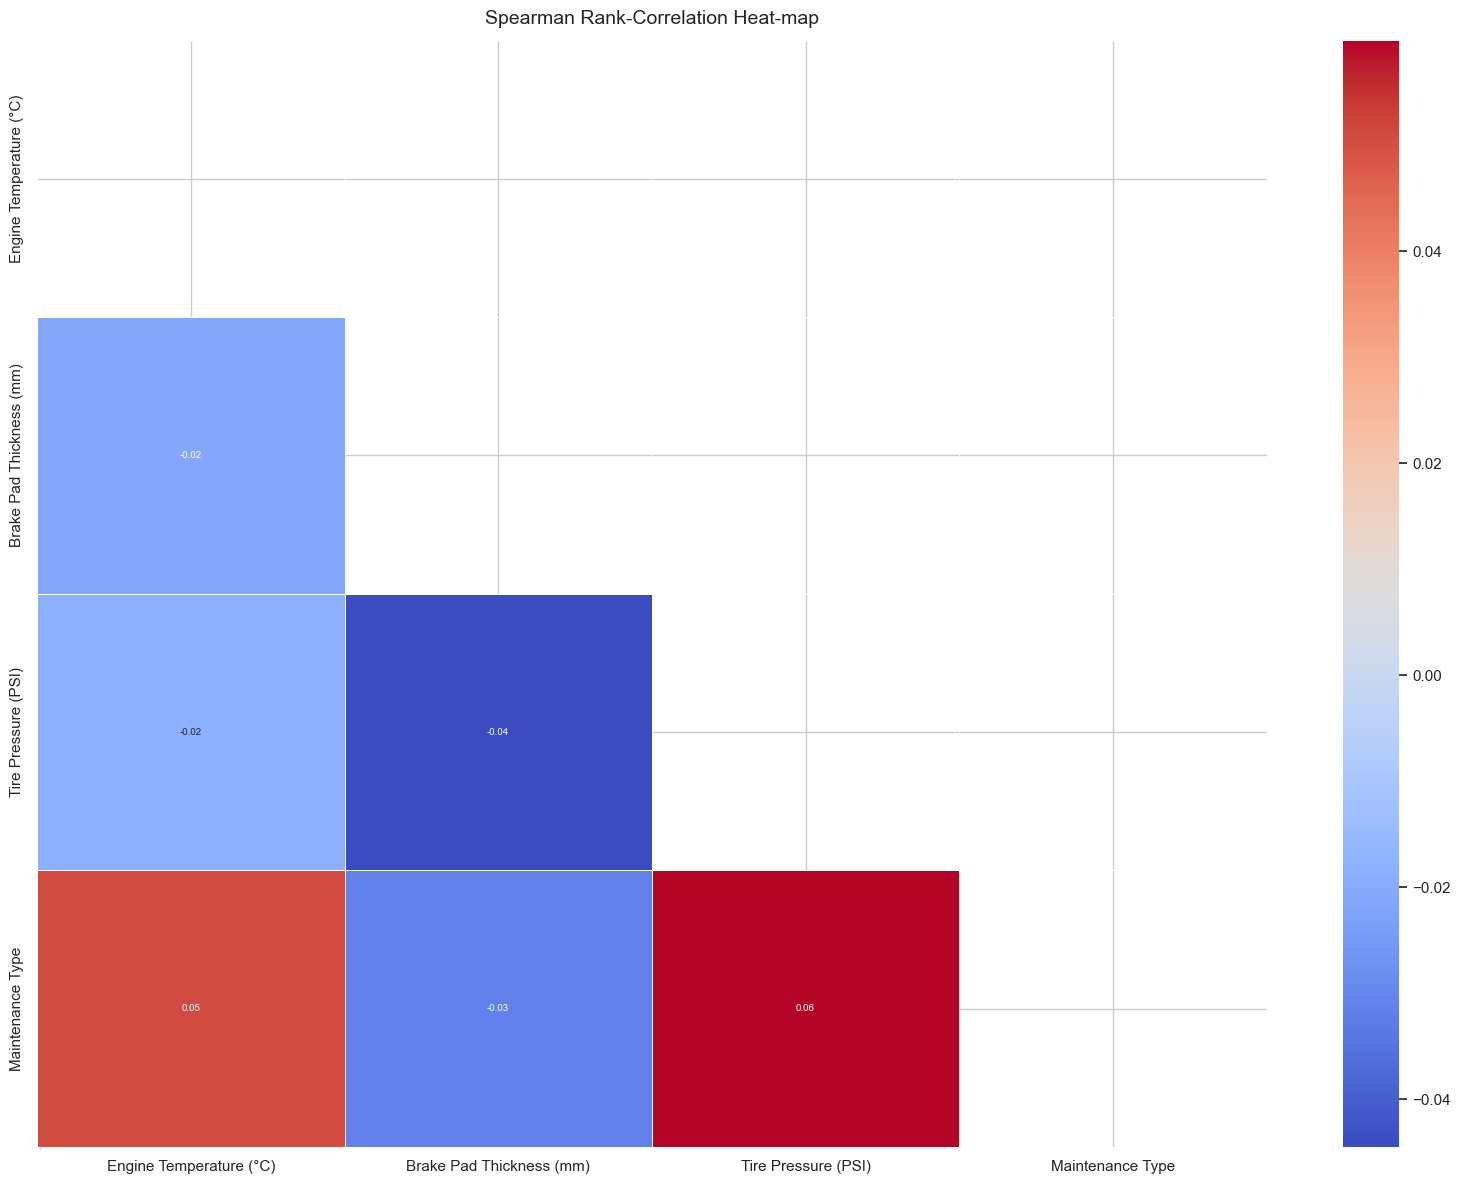

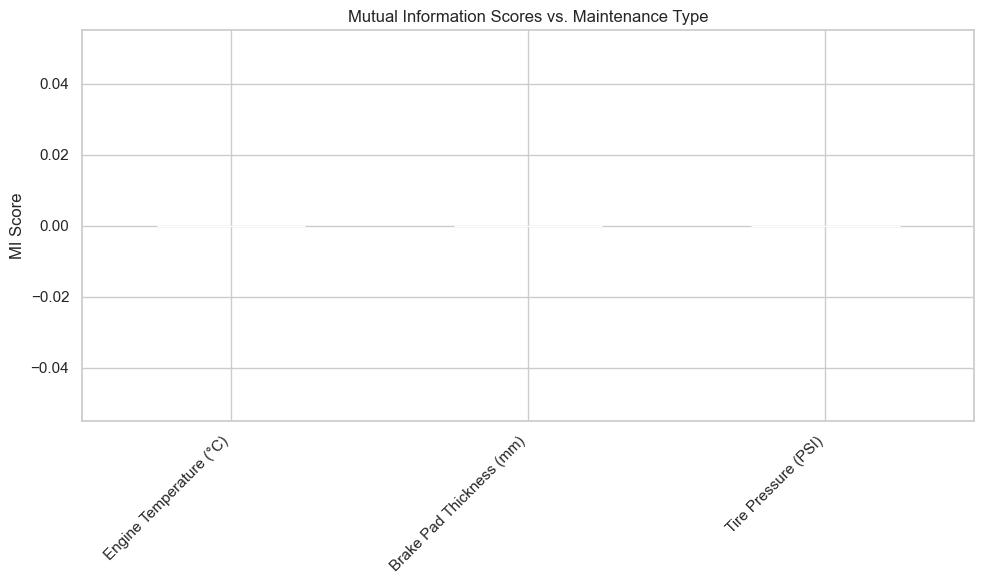

In [31]:
# Encode categorical columns, compute Spearman correlation heatmap, calculate mutual information scores,
# and drop features with zero predictive power toward the target variable

df_encoded = df.copy()
cat_cols_tmp = df_encoded.select_dtypes(include="object").columns.tolist()
le = LabelEncoder()
for c in cat_cols_tmp:
    df_encoded[c] = le.fit_transform(df_encoded[c].astype(str))

spearman_corr = df_encoded.corr(method="spearman")

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))
sns.heatmap(
    spearman_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size": 7},
)
plt.title("Spearman Rank-Correlation Heat-map", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

X_tmp = df_encoded.drop(columns=["Maintenance Type"])
y_tmp = df_encoded["Maintenance Type"]

mi_scores = mutual_info_classif(X_tmp, y_tmp, discrete_features="auto", random_state=42)
mi_series = pd.Series(mi_scores, index=X_tmp.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
mi_series.plot(kind="bar", color="steelblue")
plt.title("Mutual Information Scores vs. Maintenance Type")
plt.ylabel("MI Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

zero_mi_features = mi_series[mi_series == 0].index.tolist()
if zero_mi_features:
    df.drop(columns=zero_mi_features, inplace=True)

In [14]:
# Define ordinal features with their ranked category orders (low → high)
ordinal_features = {
    "Maintenance_History": ["Poor", "Average", "Good"],
    "Tire_Condition":      ["Worn Out", "Good", "New"],
    "Brake_Condition":     ["Worn Out", "Good", "New"],
    "Battery_Status":      ["Weak", "Good", "Strong"],
}

# Define nominal features (no natural order) that exist in the dataframe
nominal_features = [
    c for c in ["Vehicle_Model", "Fuel_Type", "Transmission_Type", "Owner_Type"]
    if c in df.columns
]

# Select all numerical columns excluding the target variable
numerical_features = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c != "Need_Maintenance"
]

# Keep only ordinal features that are present in the dataframe
ordinal_features = {k: v for k, v in ordinal_features.items() if k in df.columns}

# Separate features (X) and target variable (y)
X = df.drop(columns=["Need_Maintenance"])
y = df["Need_Maintenance"]

# Split data into 80% train and 20% test, stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
ordinal_transformer = OrdinalEncoder(
    categories=[ordinal_features[k] for k in ordinal_features],
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)

nominal_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
)

numerical_transformer = RobustScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("ord", ordinal_transformer,  list(ordinal_features.keys())),
        ("nom", nominal_transformer,  nominal_features),
        ("num", numerical_transformer, numerical_features),
    ],
    remainder="drop",
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

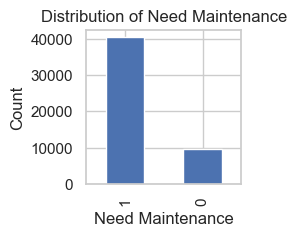

In [16]:
value_counts = df['Need_Maintenance'].value_counts()

plt.figure(figsize=(2, 2))

# Create the bar plot
value_counts.plot(kind='bar')

# Customize the plot (optional)
plt.xlabel('Need Maintenance')
plt.ylabel('Count')
plt.title('Distribution of Need Maintenance')

# Show the plot
plt.show()

### Class Imbalace detected

In [17]:
# Handle class imbalance with SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_proc, y_train)

In [22]:
X_train_sm.shape, y_train_sm.shape

((64796, 26), (64796,))

ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start


### ClearML for hyper-parametere tracking and performace analysis

In [1]:
import numpy as np
import tensorflow as tf

from clearml import Task, Logger
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, classification_report

from keras import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Input
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.regularizers import l2

### Start ClearML task

In [19]:
task = Task.init(
    project_name="605-project",
    task_name="ANN Binary Classification",
    reuse_last_task_id=False
)

logger = Logger.current_logger()

ClearML Task: created new task id=664047e54d5343aa96227c93369f4299
ClearML results page: https://app.clear.ml/projects/63ec7c9b7baa48e19de8074eda0b433d/experiments/664047e54d5343aa96227c93369f4299/output/log


### Hyperparameters

In [20]:
params = {
    "random_state": 42,
    "test_size": 0.2,
    "batch_size": 64,
    "epochs": 50,
    "learning_rate": 0.001,
    "optimizer": "adam",
    "activation": "relu",
    "num_layers": 2,
    "units_layer_1": 128,
    "units_layer_2": 64,
    "units_layer_3": 32,
    "dropout": 0.3,
    "l2_reg": 1e-4,
    "batch_norm": True,
    "use_class_weights": True
}

params = task.connect(params)

### Train/validation split and scaling

In [24]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_sm,
    y_train_sm,
    test_size=params["test_size"],
    random_state=params["random_state"],
    stratify=y_train_sm
)

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_val = scaler.transform(X_val)

print("Train shape:", X_tr.shape)
print("Validation shape:", X_val.shape)

Train shape: (51836, 26)
Validation shape: (12960, 26)


### Class weights

In [25]:
class_weight = None

if params["use_class_weights"]:
    classes = np.unique(y_tr)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_tr
    )
    class_weight = {int(c): float(w) for c, w in zip(classes, weights)}

print("Class weights:", class_weight)

Class weights: {0: 1.0, 1: 1.0}


### Build ANN model

In [27]:
model = Sequential()
model.add(Input(shape=(X_tr.shape[1],)))

for i in range(params["num_layers"]):
    units = params[f"units_layer_{i+1}"]
    model.add(Dense(
        units,
        activation=params["activation"],
        kernel_regularizer=l2(params["l2_reg"])
    ))
    
    if params["batch_norm"]:
        model.add(BatchNormalization())
    
    model.add(Dropout(params["dropout"]))

model.add(Dense(1, activation="sigmoid"))

if params["optimizer"] == "adam":
    optimizer = tf.keras.optimizers.Adam(learning_rate=params["learning_rate"])
elif params["optimizer"] == "rmsprop":
    optimizer = tf.keras.optimizers.RMSprop(learning_rate=params["learning_rate"])
else:
    optimizer = tf.keras.optimizers.SGD(learning_rate=params["learning_rate"], momentum=0.9)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,545 (49.00 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 384 (1.50 KB)

### Train model

In [28]:
early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_auc",
    mode="max",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=params["epochs"],
    batch_size=params["batch_size"],
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight,
    verbose=1
)

Epoch 1/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8578 - auc: 0.9213 - loss: 0.3507 - precision: 0.8988 - recall: 0.8064 - val_accuracy: 0.9367 - val_auc: 0.9895 - val_loss: 0.1741 - val_precision: 0.9961 - val_recall: 0.8769 - learning_rate: 0.0010
Epoch 2/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9545 - auc: 0.9906 - loss: 0.1365 - precision: 0.9711 - recall: 0.9370 - val_accuracy: 0.9903 - val_auc: 0.9992 - val_loss: 0.0519 - val_precision: 0.9995 - val_recall: 0.9810 - learning_rate: 0.0010
Epoch 3/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9789 - auc: 0.9967 - loss: 0.0765 - precision: 0.9836 - recall: 0.9740 - val_accuracy: 0.9927 - val_auc: 0.9994 - val_loss: 0.0385 - val_precision: 0.9998 - val_recall: 0.9855 - learning_rate: 0.0010
Epoch 4/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9851 - auc: 0.9980 - loss: 0.0580 - precision: 0.9877 - recall: 0.9825 - val_accuracy: 0.9930 - val_auc: 0.9993 - val_loss: 0.0354 - val

### Evaluate model

In [29]:
y_val_prob = model.predict(X_val).ravel()
y_val_pred = (y_val_prob >= 0.5).astype(int)

val_auc = roc_auc_score(y_val, y_val_prob)
val_f1 = f1_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, zero_division=0)
val_recall = recall_score(y_val, y_val_pred, zero_division=0)

print("Validation AUC      :", round(val_auc, 5))
print("Validation F1       :", round(val_f1, 5))
print("Validation Precision:", round(val_precision, 5))
print("Validation Recall   :", round(val_recall, 5))

print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred, zero_division=0))

405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step
Validation AUC      : 1.0
Validation F1       : 0.99807
Validation Precision: 1.0
Validation Recall   : 0.99614

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6480
           1       1.00      1.00      1.00      6480

    accuracy                           1.00     12960
   macro avg       1.00      1.00      1.00     12960
weighted avg       1.00      1.00      1.00     12960



### Log metrics to ClearML

In [30]:
logger.report_scalar("validation", "auc", iteration=0, value=float(val_auc))
logger.report_scalar("validation", "f1", iteration=0, value=float(val_f1))
logger.report_scalar("validation", "precision", iteration=0, value=float(val_precision))
logger.report_scalar("validation", "recall", iteration=0, value=float(val_recall))

### Save model

In [31]:
model.save("best_ann_model.keras")
task.upload_artifact("scaler_mean", scaler.mean_)
task.upload_artifact("scaler_scale", scaler.scale_)

print("Model saved and artifacts uploaded to ClearML")
print("Task ID:", task.id)

Model saved and artifacts uploaded to ClearML
Task ID: 664047e54d5343aa96227c93369f4299


ClearML Monitor: Reporting detected, reverting back to iteration based reporting


### HPO with ClearML

In [35]:
from clearml import Task
from clearml.automation import HyperParameterOptimizer
from clearml.automation.parameters import UniformParameterRange, DiscreteParameterRange

base_task_id = task.id
task.close() 

optimizer_task = Task.init(
    project_name="605-project",
    task_name="ANN Binary Classification",
    task_type=Task.TaskTypes.optimizer,
    reuse_last_task_id=False
)

optimizer = HyperParameterOptimizer(
    base_task_id=base_task_id,
    hyper_parameters=[
        DiscreteParameterRange("General/batch_size", values=[32, 64, 128]),
        UniformParameterRange("General/learning_rate", min_value=0.0001, max_value=0.005, step_size=0.0005),
        DiscreteParameterRange("General/optimizer", values=["adam", "rmsprop"]),
        DiscreteParameterRange("General/activation", values=["relu", "elu"]),
        DiscreteParameterRange("General/num_layers", values=[1, 2, 3]),
        DiscreteParameterRange("General/units_layer_1", values=[64, 128, 256]),
        DiscreteParameterRange("General/units_layer_2", values=[32, 64, 128]),
        DiscreteParameterRange("General/units_layer_3", values=[16, 32, 64]),
        UniformParameterRange("General/dropout", min_value=0.1, max_value=0.5, step_size=0.1),
        UniformParameterRange("General/l2_reg", min_value=1e-5, max_value=1e-3, step_size=1e-4),
        DiscreteParameterRange("General/batch_norm", values=[True, False]),
    ],
    objective_metric_title="validation",
    objective_metric_series="auc",
    objective_metric_sign="max",
    max_number_of_concurrent_tasks=2,
    execution_queue="default",
    save_top_k_tasks_only=5,
    total_max_jobs=20,
    min_iteration_per_job=10,
    max_iteration_per_job=50,
)

optimizer.start()
print("Hyperparameter optimization started")

ClearML Task: created new task id=13a0aac0878c44649ab1959982308c18


ClearML results page: https://app.clear.ml/projects/63ec7c9b7baa48e19de8074eda0b433d/experiments/13a0aac0878c44649ab1959982308c18/output/log
Hyperparameter optimization started


Progress report #0 completed, sleeping for 0.25 minutes
Progress report #1 completed, sleeping for 5.0 minutes
Progress report #2 completed, sleeping for 5.0 minutes
Progress report #3 completed, sleeping for 5.0 minutes
Progress report #4 completed, sleeping for 5.0 minutes
Progress report #5 completed, sleeping for 5.0 minutes
Progress report #6 completed, sleeping for 5.0 minutes
